# Live DMM Voltage Plot
Stream voltage measurements from a connected DMM. Falls back to a simulator if no VISA device is found.


In [7]:
import time, random, math
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
from collections import deque

try:
    import pyvisa
except Exception:
    pyvisa = None


Matplotlib is building the font cache; this may take a moment.


In [8]:
class SimDMM:
    def __init__(self):
        self.t0 = time.time()
    def read_voltage(self):
        t = time.time() - self.t0
        return 1.0 + 0.1*math.sin(2*math.pi*0.2*t) + random.uniform(-0.01, 0.01)

class VisaDMM:
    def __init__(self, resource):
        if pyvisa is None:
            raise RuntimeError("pyvisa not available")
        self.rm = pyvisa.ResourceManager()
        self.inst = self.rm.open_resource(resource)
        try:
            self.inst.timeout = 2000
        except Exception:
            pass
        # Basic setup; tolerate instruments that don't support these
        for cmd in ["*RST", "SENS:FUNC 'VOLT:DC'"]:
            try:
                self.inst.write(cmd)
            except Exception:
                pass
    def read_voltage(self):
        # Prefer a direct DCV reading. Fallback to READ? if needed.
        try:
            return float(self.inst.query("MEAS:VOLT:DC?"))
        except Exception:
            return float(self.inst.query("READ?"))
    def close(self):
        try:
            self.inst.close()
        except Exception:
            pass
        try:
            self.rm.close()
        except Exception:
            pass

def find_dmm(resource_hint=None):
    resources = []
    if pyvisa is None:
        return None, resources
    rm = pyvisa.ResourceManager()
    try:
        resources = list(rm.list_resources()) or []
    finally:
        try:
            rm.close()
        except Exception:
            pass
    if resource_hint:
        return resource_hint, resources
    # Heuristics: pick a likely instrument resource
    for r in resources:
        R = r.upper()
        if any(k in R for k in ["USB", "GPIB", "ASRL", "TCPIP"]):
            return r, resources
    return None, resources

def live_voltage_plot(resource_hint=None, interval=0.25, window=200, simulate_if_missing=True):
    """
    Render a live-updating voltage chart from a VISA DMM.
    - resource_hint: optional VISA resource string (e.g., 'USB0::...::INSTR').
    - interval: sample period in seconds.
    - window: number of recent points to display.
    - simulate_if_missing: fall back to a simulated DMM if none found.
    Stop the cell (Kernel -> Interrupt) to end the stream.
    """
    resource, resources = find_dmm(resource_hint)
    print("VISA resources:", resources)
    dmm = None
    using_sim = False
    try:
        if resource and pyvisa is not None:
            print(f"Using DMM: {resource}")
            dmm = VisaDMM(resource)
        elif simulate_if_missing:
            print("No DMM found; using simulator.")
            using_sim = True
            dmm = SimDMM()
        else:
            raise RuntimeError("No DMM found and simulation disabled.")

        xs, ys = deque(maxlen=window), deque(maxlen=window)
        start = time.time()
        fig, ax = plt.subplots(figsize=(7, 3))
        (line,) = ax.plot([], [], lw=1.5)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Voltage (V)')
        ax.set_title('Live DMM Voltage' + (' (Simulated)' if using_sim else ''))
        ax.grid(True)
        display(fig)

        while True:
            v = dmm.read_voltage()
            t = time.time() - start
            xs.append(t); ys.append(v)
            line.set_data(list(xs), list(ys))
            ax.relim(); ax.autoscale_view()
            ax.set_xlim(max(0, t - interval*window), t + 0.25)
            fig.canvas.draw_idle()
            clear_output(wait=True); display(fig)
            time.sleep(interval)
    except KeyboardInterrupt:
        print('Stopped.')
    finally:
        if isinstance(dmm, VisaDMM):
            dmm.close()


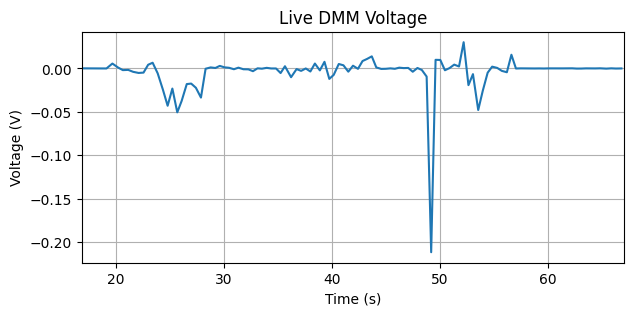

Stopped.


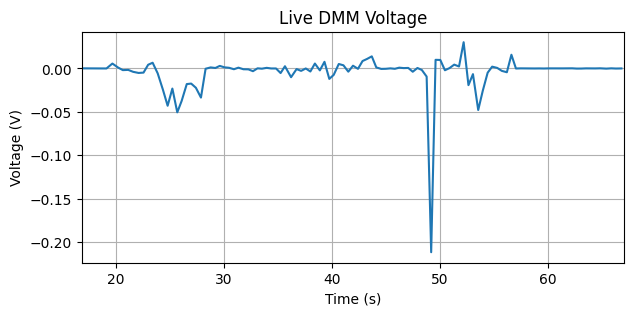

In [9]:
# Start the live plot.
# If you know your VISA resource string, pass it via resource_hint, e.g.:
# live_voltage_plot(resource_hint="USB0::0x05E6::0x2100::1234567::INSTR")
live_voltage_plot(interval=0.25, window=200)
